In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)

MODEL_DIR    = Path('../results/models')
FIG_DIR      = Path('../results/figures')
FEATURES_DIR = Path('../results/features')
FIG_DIR.mkdir(parents=True, exist_ok=True)

pred_svm     = joblib.load(MODEL_DIR / 'pred_svm.pkl')
pred_hibrido = joblib.load(MODEL_DIR / 'pred_hibrido.pkl')
y_test       = joblib.load(MODEL_DIR / 'y_test.pkl')
fuente       = joblib.load(MODEL_DIR / 'fuente.pkl')
confianza    = joblib.load(MODEL_DIR / 'confianza.pkl')
df_test      = pd.read_csv(FEATURES_DIR / 'features_test.csv')

clases = sorted(np.unique(y_test))
print('Todo cargado.')

Todo cargado.


In [3]:
acc_svm      = accuracy_score(y_test, pred_svm)
acc_hibrido  = accuracy_score(y_test, pred_hibrido)

print('=== RESUMEN FINAL ===')
print(f'SVM solo     : {acc_svm:.3f}')
print(f'Híbrido      : {acc_hibrido:.3f}')
print(f'\nMejora absoluta: +{acc_hibrido - acc_svm:.3f}')
print(f'Imágenes resueltas por SVM : {fuente.count("SVM")} ({fuente.count("SVM")/len(fuente):.1%})')
print(f'Imágenes resueltas por CNN : {fuente.count("CNN")} ({fuente.count("CNN")/len(fuente):.1%})')

=== RESUMEN FINAL ===
SVM solo     : 0.693
Híbrido      : 0.842

Mejora absoluta: +0.149
Imágenes resueltas por SVM : 4412 (62.2%)
Imágenes resueltas por CNN : 2684 (37.8%)


             SVM  Híbrido  Delta
battery    0.690    0.885  0.195
metal      0.602    0.794  0.192
glass      0.614    0.776  0.162
plastic    0.563    0.717  0.155
textile    0.777    0.920  0.144
cardboard  0.703    0.839  0.136
paper      0.689    0.820  0.131
organic    0.805    0.921  0.116
trash      0.740    0.854  0.113


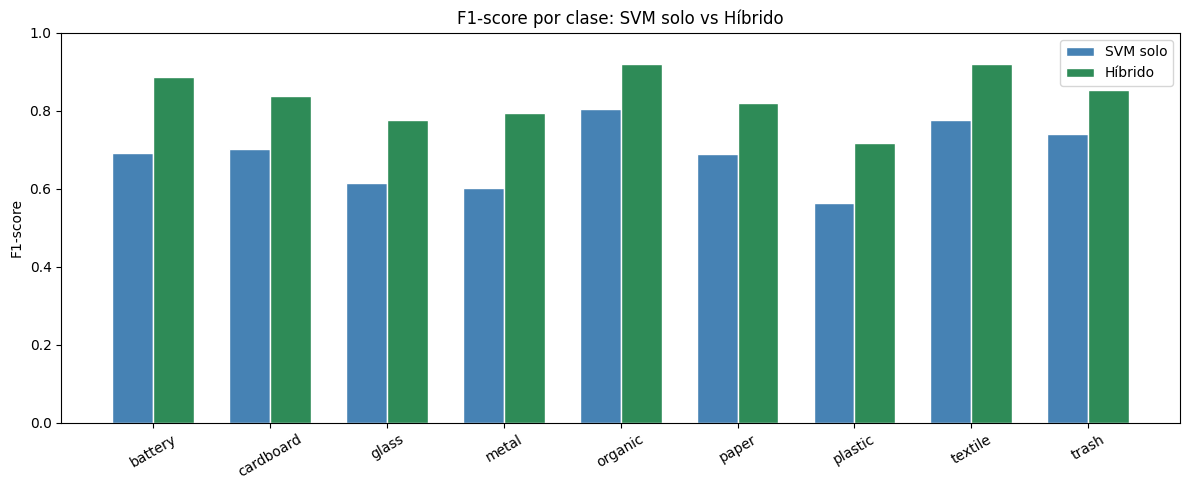

In [4]:
f1_svm     = f1_score(y_test, pred_svm,     average=None, labels=clases)
f1_hibrido = f1_score(y_test, pred_hibrido, average=None, labels=clases)

df_f1 = pd.DataFrame({
    'SVM':     f1_svm,
    'Híbrido': f1_hibrido,
    'Delta':   f1_hibrido - f1_svm
}, index=clases).sort_values('Delta', ascending=False)

print(df_f1.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(clases))
width  = 0.35
ax.bar(x - width/2, df_f1.loc[clases, 'SVM'],     width, label='SVM solo',  color='steelblue',  edgecolor='white')
ax.bar(x + width/2, df_f1.loc[clases, 'Híbrido'], width, label='Híbrido',   color='seagreen',   edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(clases, rotation=30)
ax.set_ylabel('F1-score')
ax.set_title('F1-score por clase: SVM solo vs Híbrido')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_f1_por_clase.png', dpi=150)
plt.show()

Tasa de activación CNN por clase:
metal        0.505
glass        0.496
battery      0.440
paper        0.403
plastic      0.389
cardboard    0.368
textile      0.317
trash        0.292
organic      0.223


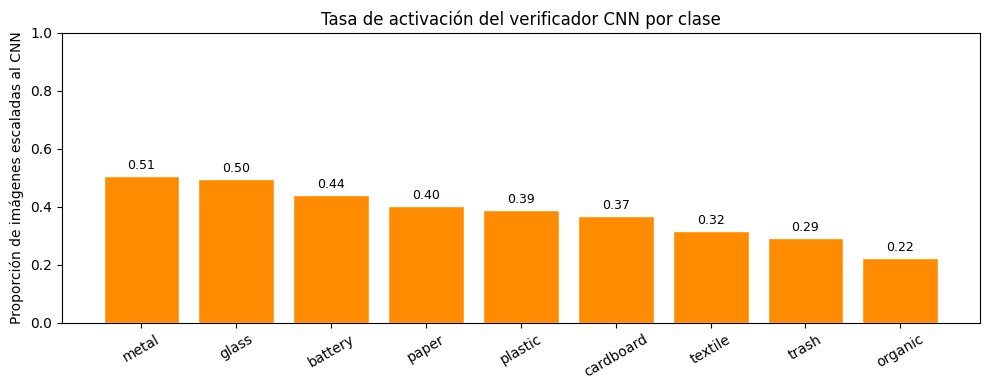

In [8]:
fuente_arr = np.array(fuente)

activacion = {}
for clase in clases:
    mask_clase   = y_test == clase
    cnn_en_clase = np.sum(fuente_arr[mask_clase] == 'CNN')
    total_clase  = np.sum(mask_clase)
    activacion[clase] = cnn_en_clase / total_clase

df_act = pd.Series(activacion).sort_values(ascending=False)
print('Tasa de activación CNN por clase:')
print(df_act.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_act.index, df_act.values, color='darkorange', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_ylabel('Proporción de imágenes escaladas al CNN')
ax.set_title('Tasa de activación del verificador CNN por clase')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_tasa_activacion_cnn.png', dpi=150)
plt.show()

In [6]:
mask_error = pred_hibrido != y_test

df_fallos = pd.DataFrame({
    'clase_real':      y_test[mask_error],
    'clase_predicha':  pred_hibrido[mask_error],
    'fuente':          fuente_arr[mask_error],
    'confianza':       confianza[mask_error],
    'archivo':         df_test['archivo'].values[mask_error]
})

print(f'Total errores híbrido: {len(df_fallos)} ({len(df_fallos)/len(y_test):.1%})')
print(f'\nErrores por fuente:')
print(df_fallos['fuente'].value_counts().to_string())

print(f'\nConfusiones más frecuentes:')
confusion_pares = df_fallos.groupby(['clase_real', 'clase_predicha']).size().sort_values(ascending=False)
print(confusion_pares.head(15).to_string())

Total errores híbrido: 1120 (15.8%)

Errores por fuente:
fuente
SVM    662
CNN    458

Confusiones más frecuentes:
clase_real  clase_predicha
plastic     trash             91
paper       cardboard         78
plastic     glass             57
glass       plastic           55
            metal             49
metal       glass             40
plastic     cardboard         31
textile     organic           30
metal       plastic           30
glass       trash             28
metal       paper             26
            battery           25
plastic     metal             23
battery     metal             23
trash       plastic           20


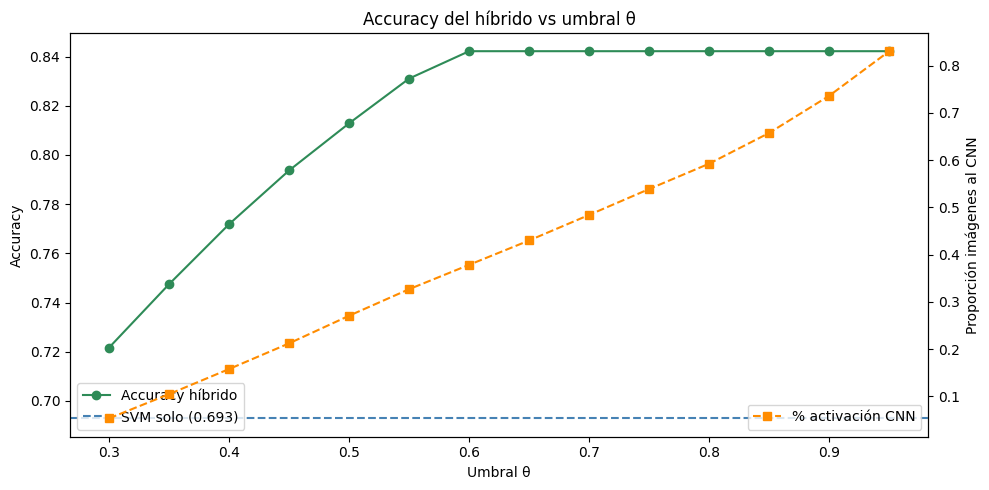

In [7]:
thetas    = np.arange(0.3, 0.96, 0.05)
acc_lista = []
cnn_ratio = []

for theta in thetas:
    pred_tmp = []
    for conf, ps, ph in zip(confianza, pred_svm, pred_hibrido):
        pred_tmp.append(ps if conf >= theta else ph)
    acc_lista.append(accuracy_score(y_test, pred_tmp))
    cnn_ratio.append(np.mean(confianza < theta))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thetas, acc_lista, color='seagreen',   marker='o', label='Accuracy híbrido')
ax1.axhline(acc_svm,     color='steelblue', linestyle='--', label=f'SVM solo ({acc_svm:.3f})')
ax1.set_xlabel('Umbral θ')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower left')

ax2.plot(thetas, cnn_ratio, color='darkorange', marker='s', linestyle='--', label='% activación CNN')
ax2.set_ylabel('Proporción imágenes al CNN')
ax2.legend(loc='lower right')

ax1.set_title('Accuracy del híbrido vs umbral θ')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_curva_accuracy_vs_theta.png', dpi=150)
plt.show()

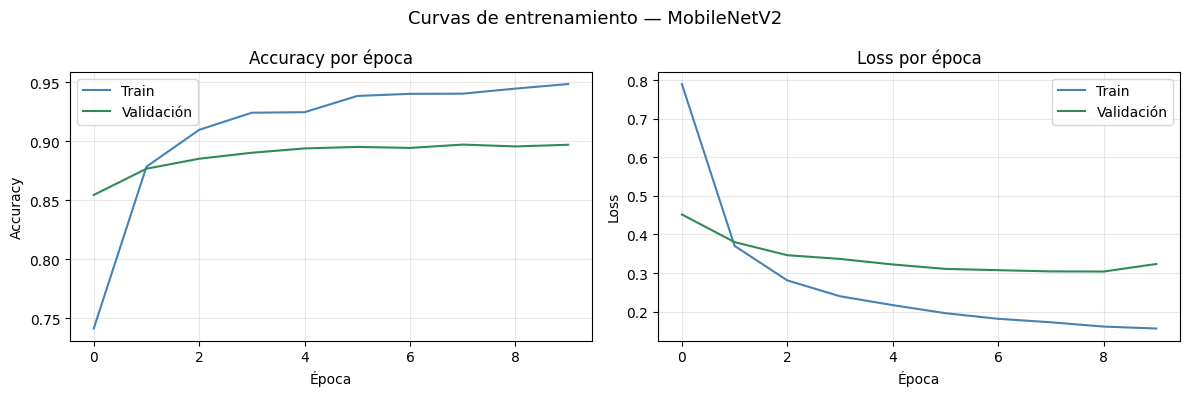

In [9]:
history = joblib.load(MODEL_DIR / 'cnn_history.pkl')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(history['val_accuracy'], label='Validación', color='seagreen')
axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['loss'],     label='Train',      color='steelblue')
axes[1].plot(history['val_loss'], label='Validación', color='seagreen')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — MobileNetV2', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_curvas_entrenamiento_cnn.png', dpi=150)
plt.show()